# Constructing EOS and solving TOV equations beyond General Relativity

This example notebook shows how to construct the equation of state with the metamodel and speed-of-sound extension scheme parametrization used in the paper, as well as solve the TOV equations beyond GR. 

In [1]:
import matplotlib.pyplot as plt
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
params = {"text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"],
          "xtick.labelsize": 16,
          "ytick.labelsize": 16,
          "axes.labelsize": 16,
          "legend.fontsize": 16,
          "legend.title_fontsize": 16}
plt.rcParams.update(params)
import jax.numpy as jnp
import jax
from jax import config
config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
# from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
# from jesterTOV.eos.families import construct_family, construct_family_nonGR, construct_family_ST, construct_family_ST_Greci, construct_family_ST_sol, construct_family_eibi
import jesterTOV.utils as utils
import time
from jesterTOV import utils
from jesterTOV.eos.metamodel import MetaModel_EOS_model, MetaModel_with_CSE_EOS_model
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver
# from jesterTOV.tov.eibi import EiBITOVSolver
from jesterTOV.tov.data_classes import EOSData

# Equation of state

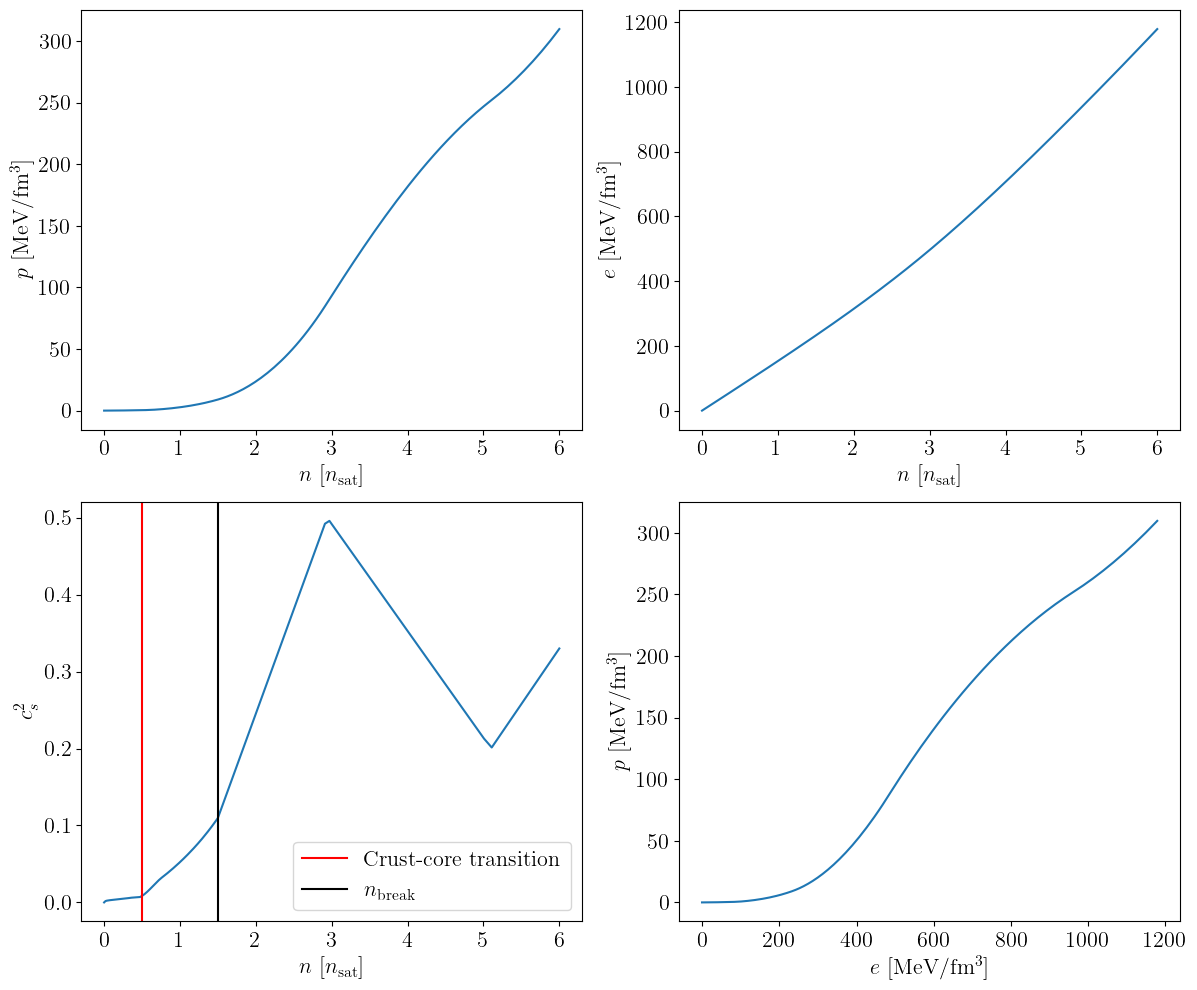

In [2]:
nsat = 0.16 # nuclear saturation density in fm^-3

# Define the EOS object, here we focus on Metamodel with CSE
nmax_nsat = 6.0
nb_CSE=4
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75,ndat_metamodel=80, ndat_CSE=70)

# Define the nuclear empirical parameters (NEPs) -- all in MeV
input_dict = {"E_sat": -16.0, # saturation parameters
            "K_sat": 200.0,
            "Q_sat": 0.0,
            "Z_sat": 0.0,
            "E_sym": 32.0, # symmetry parameters
            "L_sym": 70.0,
            "K_sym": -100.0,
            "Q_sym": 0.0,
            "Z_sym": 0.0,
            "nbreak": 1.5 * nsat,
            }


# Then we extend with some CSE grid points
ngrids = jnp.array([2.0, 3.0, 4.0, 5.0]) * nsat
cs2grids = jnp.array([0.5, 0.4, 0.3, 0.2]) # speed of sound squared at the grid points
# Add CSE grid parameters (normalized positions and cs2 values)
input_dict["n_CSE_0_u"] = ngrids[0]
input_dict["cs2_CSE_0"] = cs2grids[0]
input_dict["n_CSE_1_u"] = ngrids[1]
input_dict["cs2_CSE_1"] = cs2grids[1]
input_dict["n_CSE_2_u"] = ngrids[2]
input_dict["cs2_CSE_2"] = cs2grids[2]
input_dict["n_CSE_3_u"] = ngrids[3]
input_dict["cs2_CSE_3"] = cs2grids[3]
input_dict["n_CSE_4_u"] = nmax_nsat
input_dict["cs2_CSE_4"] = 0.33  # Final cs2 value

# Now create the EOS -- returns a tuple with most useful EOS quantities
eos_output= eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 =  eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# 1. Neutron stars in Standard Scalar-Tensor Theory

##### Solving the TOV equations to construct an M(R) curve and calculate their tidal deformabilities based on Gastón Creci, Tanja Hinderer, Jan Steinhoff Phys.Rev.D 108 (2023) 12, 124073

Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 7 beta values finished in 35.2593 seconds.


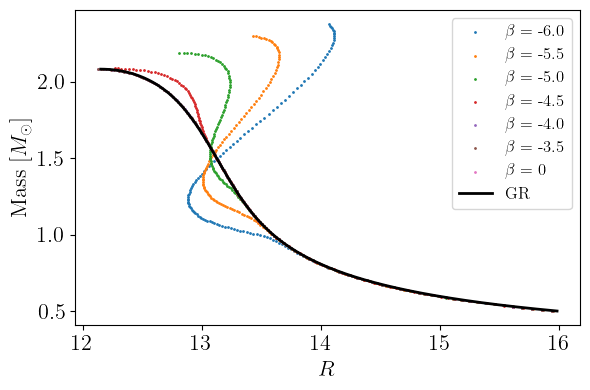

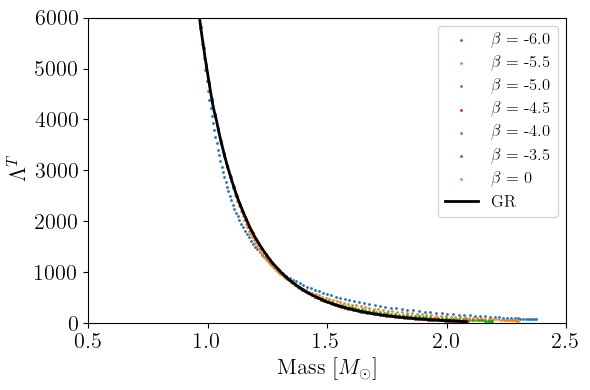

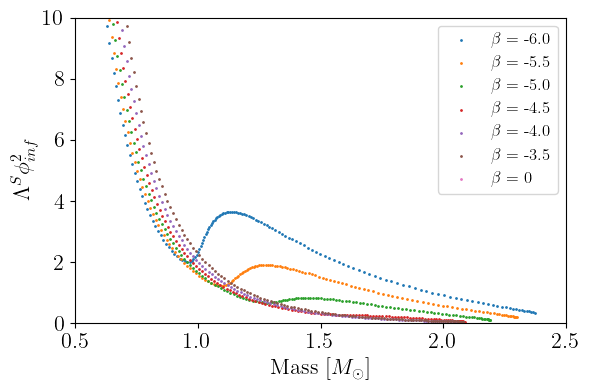

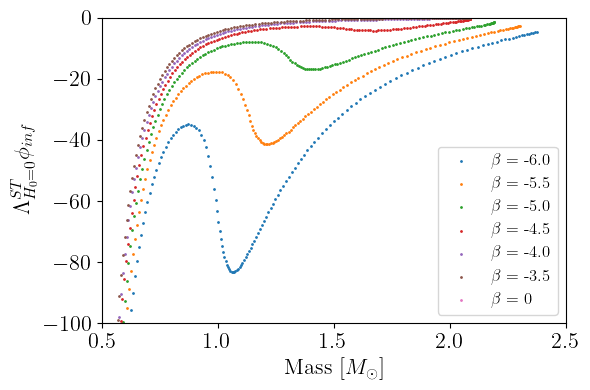

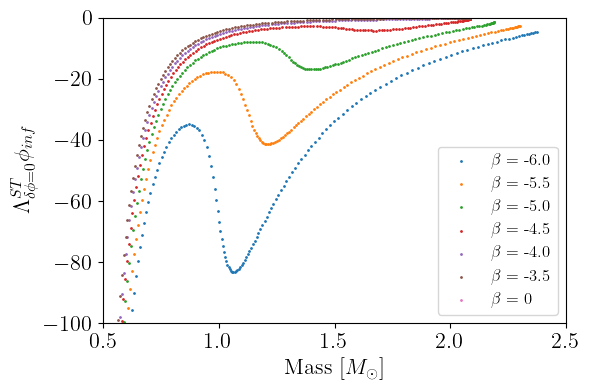

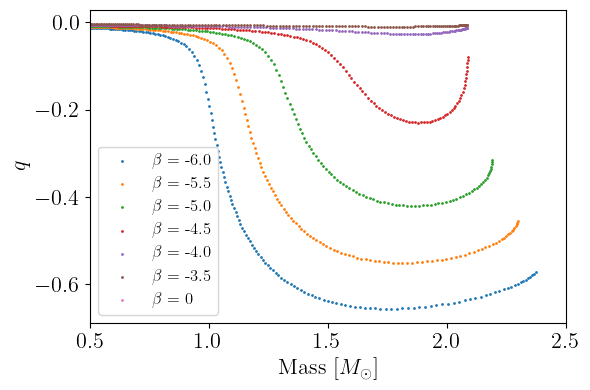

In [3]:
import jax.numpy as jnp                                                                                                    
import jax                                                                                                               
import matplotlib.pyplot as plt                                                                                            
import time                                                                                                                

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# Parameters
beta_values = [-6.0, -5.5, -5.0, -4.5, -4.0, -3.5, 0]
# beta_values = [-5-1e-14, -5.0, -5+1e-14]
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData (assuming ns, ps, hs, es, dloge_dlogps, cs2 are defined)
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results - filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter( data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot( gr_radii, gr_masses,label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$")
# plt.ylim(0, 6000)
# plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()


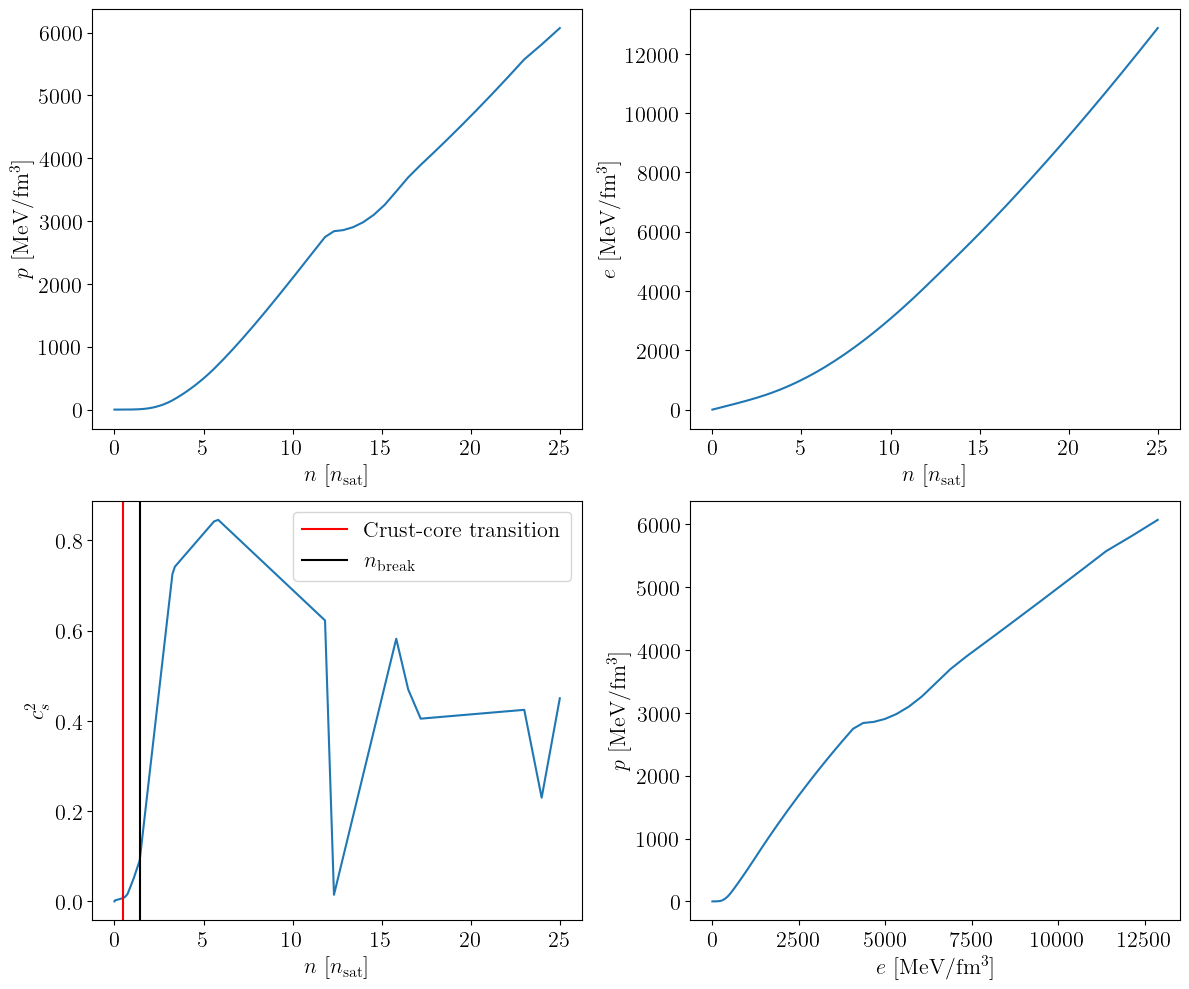

Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 1 beta values finished in 21.5556 seconds.


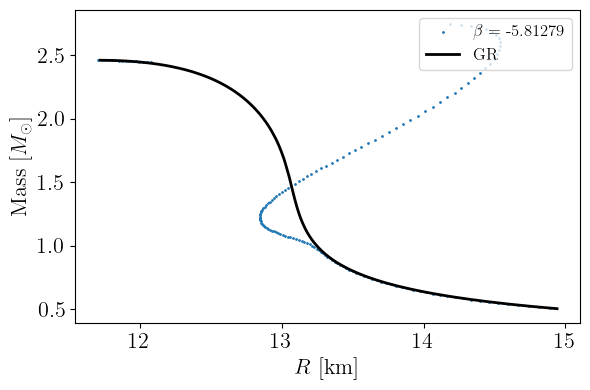

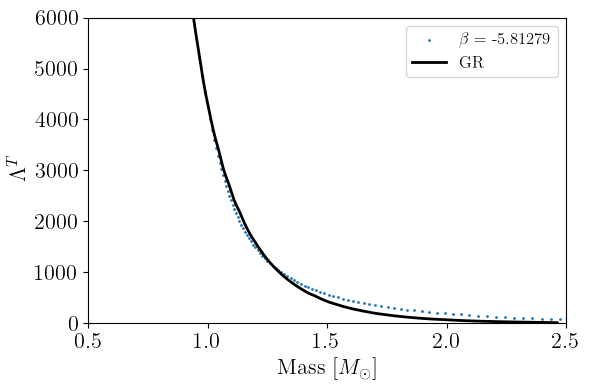

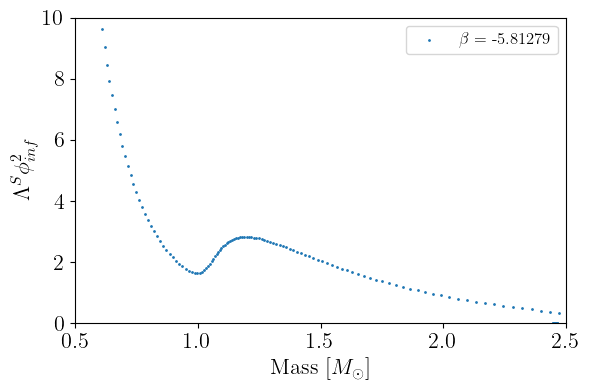

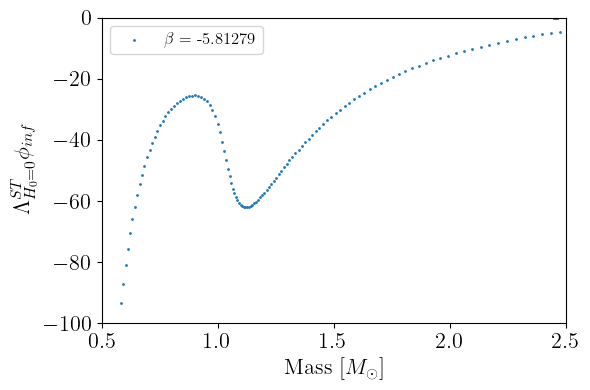

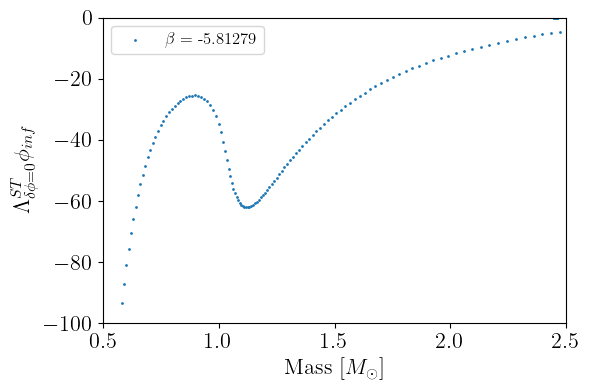

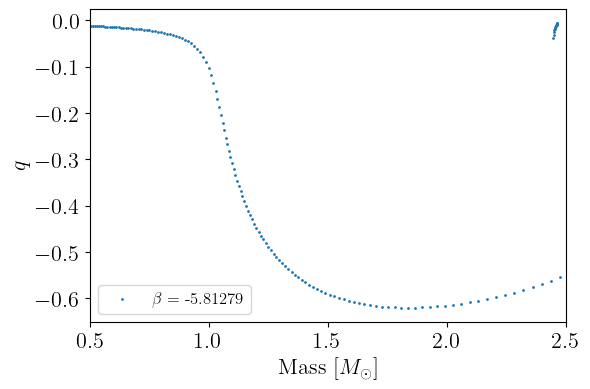

In [4]:
import jax.numpy as jnp                                                                                                   
import jax                                                                                                                
import matplotlib.pyplot as plt                                                                                           
import time                                                                                                               

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# 1. Parse the provided input parameters
# input_data_str = """
# E_sat           | -1.59033e+01
# E_sym           | 3.22901e+01
# K_sat           | 2.61895e+02
# K_sym           | -2.74780e+02
# L_sym           | 7.34811e+01
# Q_sat           | 9.22315e+02
# Q_sym           | 1.01438e+03
# Z_sat           | -2.14998e+03
# Z_sym           | 1.25886e+03
# beta_ST         | -3.49905e+00
# cs2_CSE_0       | 5.56906e-01
# cs2_CSE_1       | 8.16552e-01
# cs2_CSE_2       | 5.65096e-02
# cs2_CSE_3       | 5.82637e-01
# cs2_CSE_4       | 8.20480e-02
# cs2_CSE_5       | 7.27966e-01
# cs2_CSE_6       | 6.29892e-01
# cs2_CSE_7       | 6.85474e-02
# cs2_CSE_8       | 1.24867e-01
# n_CSE_0_u       | 9.19373e-01
# n_CSE_1_u       | 5.41673e-01
# n_CSE_2_u       | 4.98518e-01
# n_CSE_3_u       | 1.53581e-01
# n_CSE_4_u       | 5.66337e-01
# n_CSE_5_u       | 2.58532e-02
# n_CSE_6_u       | 6.04648e-01
# n_CSE_7_u       | 7.44154e-01
# nbreak          | 2.58339e-01
# """

# input_data_str = """
# E_sat           | -1.60026e+01
# E_sym           | 2.98435e+01
# K_sat           | 1.81830e+02
# K_sym           | -6.34947e+01
# L_sym           | 3.44000e+01
# Q_sat           | 2.45076e+01
# Q_sym           | -3.07306e+02
# Z_sat           | -2.10266e+03
# Z_sym           | 7.83766e+02
# beta_ST         | -4.73928e+00
# cs2_CSE_0       | 3.03478e-01
# cs2_CSE_1       | 9.60489e-01
# cs2_CSE_2       | 3.80998e-01
# cs2_CSE_3       | 3.91384e-01
# cs2_CSE_4       | 6.16758e-01
# cs2_CSE_5       | 1.28236e-01
# cs2_CSE_6       | 2.07682e-01
# cs2_CSE_7       | 2.94126e-01
# cs2_CSE_8       | 3.20858e-02
# n_CSE_0_u       | 5.77547e-01
# n_CSE_1_u       | 7.18056e-01
# n_CSE_2_u       | 1.28820e-01
# n_CSE_3_u       | 3.08105e-01
# n_CSE_4_u       | 5.70248e-01
# n_CSE_5_u       | 2.54953e-01
# n_CSE_6_u       | 7.86629e-01
# n_CSE_7_u       | 8.25210e-01
# nbreak          | 2.14433e-01
# """

input_data_str =  """
E_sat           | -1.60688e+01
E_sym           | 3.86202e+01
K_sat           | 1.65255e+02
K_sym           | 9.83160e+01
L_sym           | 2.35620e+01
Q_sat           | 2.45020e+02
Q_sym           | -6.95586e+02
Z_sat           | -4.46984e+02
Z_sym           | -1.72807e+03
_random_key     | 1.52656e+09
beta_ST         | -5.81279e+00
cs2_CSE_0       | 7.36893e-01
cs2_CSE_1       | 8.48778e-01
cs2_CSE_2       | 6.13429e-01
cs2_CSE_3       | 8.98158e-03
cs2_CSE_4       | 5.88126e-01
cs2_CSE_5       | 4.03804e-01
cs2_CSE_6       | 4.24797e-01
cs2_CSE_7       | 7.77889e-02
cs2_CSE_8       | 4.50180e-01
n_CSE_0_u       | 9.86674e-01
n_CSE_1_u       | 4.51662e-01
n_CSE_2_u       | 6.54113e-01
n_CSE_3_u       | 7.93539e-02
n_CSE_4_u       | 6.12247e-01
n_CSE_5_u       | 1.83258e-01
n_CSE_6_u       | 9.18473e-01
n_CSE_7_u       | 4.60962e-01
nbreak          | 2.26484e-01
"""

input_dict = {}
for line in input_data_str.strip().split('\n'):
    key, val = line.split('|')
    input_dict[key.strip()] = float(val.strip())

# Extract beta_ST for the TOV solver
beta_values = [input_dict.pop("beta_ST")]

nsat = 0.16 # nuclear saturation density in fm^-3
nmax_nsat = 25.0
nb_CSE = 8 # Updated to 8 to match the provided inputs (indices 0 to 8)

# Define the EOS object, here we focus on Metamodel with CSE
# Note: assuming MetaModel_with_CSE_EOS_model is imported or defined elsewhere in your workspace
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70)

# Set the final grid density point explicitly as done in the original code
input_dict["n_CSE_8_u"] = nmax_nsat

# Now create the EOS, returns a tuple with most useful EOS quantities
eos_output = eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 = eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# Parameters for TOV
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData 
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results, filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

# ============================================
# Plot 0: Mass vs Radius
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_radii, gr_masses, label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$ [km]")
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

[14.89391796 14.81522643 14.73971486 14.66620124 14.59434261 14.5249087
 14.45858625 14.39520965 14.33457082 14.27688172 14.22183905 14.1682929
 14.11600281 14.06564851 14.01783517 13.97242555 13.92889542 13.88713634
 13.84714292 13.80848888 13.77109657 13.73524992 13.70124754 13.66902081
 13.6380566  13.60808788 13.57935944 13.55212856 13.52651384 13.50208141
 13.47845432 13.45577666 13.43409789 13.41346635 13.39381385 13.37503852
 13.35721461 13.34013349 13.32368275 13.30791196 13.29240293 13.27719237
 13.26212251 13.24677911 13.23136287 13.21535656 13.19830609 13.18042239
 13.16175781 13.14202202 13.12175932 13.10180412 13.08192712 13.06242981
 13.04356155 13.0252062  13.0074946  12.99034213 12.9739352  12.95859788
 12.94429172 12.93083557 12.91806295 12.90609326 12.89523264 12.88551551
 12.8768861  12.8693632  12.86295855 12.85756796 12.85308854 12.84960351
 12.8472878  12.84612632 12.84615274 12.84744959 12.84999772 12.85375652
 12.85867276 12.86480213 12.8722804  12.8811246  12.8

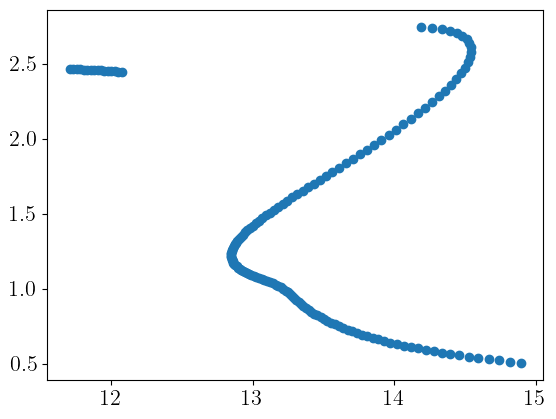

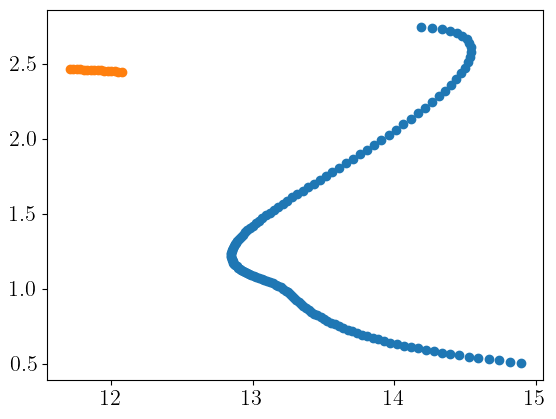

[14.89391796 14.81522643 14.73971486 14.66620124 14.59434261 14.5249087
 14.45858625 14.39520965 14.33457082 14.27688172 14.22183905 14.1682929
 14.11600281 14.06564851 14.01783517 13.97242555 13.92889542 13.88713634
 13.84714292 13.80848888 13.77109657 13.73524992 13.70124754 13.66902081
 13.6380566  13.60808788 13.57935944 13.55212856 13.52651384 13.50208141
 13.47845432 13.45577666 13.43409789 13.41346635 13.39381385 13.37503852
 13.35721461 13.34013349 13.32368275 13.30791196 13.29240293 13.27719237
 13.26212251 13.24677911 13.23136287 13.21535656 13.19830609 13.18042239
 13.16175781 13.14202202 13.12175932 13.10180412 13.08192712 13.06242981
 13.04356155 13.0252062  13.0074946  12.99034213 12.9739352  12.95859788
 12.94429172 12.93083557 12.91806295 12.90609326 12.89523264 12.88551551
 12.8768861  12.8693632  12.86295855 12.85756796 12.85308854 12.84960351
 12.8472878  12.84612632 12.84615274 12.84744959 12.84999772 12.85375652
 12.85867276 12.86480213 12.8722804  12.8811246  12.8

In [5]:
print(data["radii"], data["masses"])
plt.scatter(data["radii"],data["masses"])
plt.show()
#split to two segment
import jax
import jax.numpy as jnp


@jax.jit
def get_split_index(x, y):
    N = x.shape[0]
    ds2 = jnp.diff(x)**2 + jnp.diff(y)**2
    
    med_ds2 = jnp.median(ds2)
    abs_deviation = jnp.abs(ds2 - med_ds2)
    
    # FIX: Enforce a minimum threshold for MAD to ignore floating-point noise
    # 1e-5 is chosen as a safe floor, assuming your macroscopic jumps are larger than this.
    mad = jnp.maximum(jnp.median(abs_deviation), 1e-5)
    
    z_score = 0.6745 * (ds2 - med_ds2) / mad
    max_idx = jnp.argmax(z_score)
    
    is_jump = (z_score[max_idx] > 3.5).astype(jnp.int32)
    
    split_idx = is_jump * (max_idx + 1) + (1 - is_jump) * N
    return split_idx

# Extract the scalar index for slicing
split_idx = int(get_split_index(data["radii"],data["masses"]))

# Slice directly without any conditional logic
x1, x2 = data["radii"][:split_idx], data["radii"][split_idx:]
y1, y2 = data["masses"][:split_idx], data["masses"][split_idx:]

plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.show()
print(x1,x2,y1,y2)

139


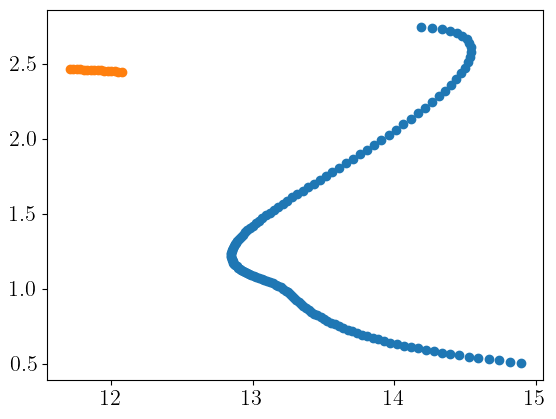

[14.89391796 14.81522643 14.73971486 14.66620124 14.59434261 14.5249087
 14.45858625 14.39520965 14.33457082 14.27688172 14.22183905 14.1682929
 14.11600281 14.06564851 14.01783517 13.97242555 13.92889542 13.88713634
 13.84714292 13.80848888 13.77109657 13.73524992 13.70124754 13.66902081
 13.6380566  13.60808788 13.57935944 13.55212856 13.52651384 13.50208141
 13.47845432 13.45577666 13.43409789 13.41346635 13.39381385 13.37503852
 13.35721461 13.34013349 13.32368275 13.30791196 13.29240293 13.27719237
 13.26212251 13.24677911 13.23136287 13.21535656 13.19830609 13.18042239
 13.16175781 13.14202202 13.12175932 13.10180412 13.08192712 13.06242981
 13.04356155 13.0252062  13.0074946  12.99034213 12.9739352  12.95859788
 12.94429172 12.93083557 12.91806295 12.90609326 12.89523264 12.88551551
 12.8768861  12.8693632  12.86295855 12.85756796 12.85308854 12.84960351
 12.8472878  12.84612632 12.84615274 12.84744959 12.84999772 12.85375652
 12.85867276 12.86480213 12.8722804  12.8811246  12.8

In [6]:
import jax
import jax.numpy as jnp

@jax.jit
def get_split_index(x, y, jump_threshold=20.0):
    N = x.shape[0]
    ds2 = jnp.diff(x)**2 + jnp.diff(y)**2
    
    # Find the largest gap
    max_idx = jnp.argmax(ds2)
    median_ds2 = jnp.median(ds2) + 1e-12
    is_jump = ((ds2[max_idx] > (jump_threshold * median_ds2)) & (max_idx > 0)).astype(jnp.int32)

    split_idx = is_jump * (max_idx + 1) + (1 - is_jump) * N
    return split_idx

# Execution
split_idx = int(utils.get_MR_split_index(data["radii"], data["masses"]))
print(split_idx)
x1, x2 = data["radii"][:split_idx], data["radii"][split_idx:]
y1, y2 = data["masses"][:split_idx], data["masses"][split_idx:]

plt.scatter(x1,y1)
plt.scatter(x2,y2)
plt.show()
print(x1,x2,y1,y2)

Generating GIF. This will take a moment as it evaluates the physics for each frame...
Saved to maryland_flow_variation.gif


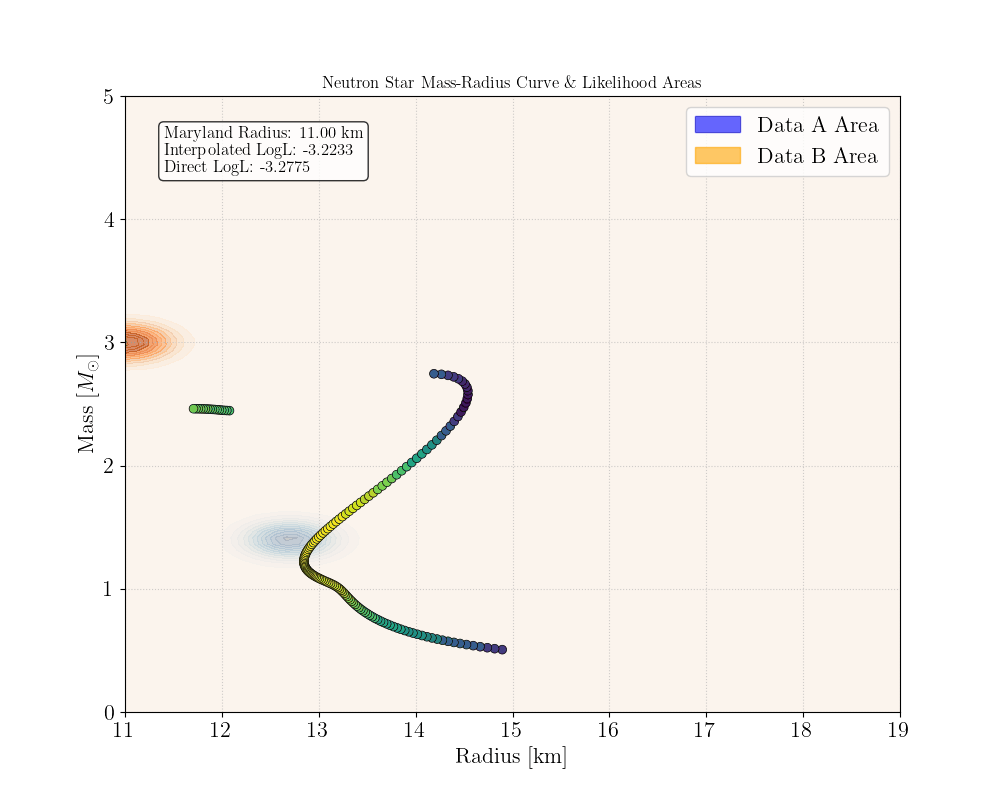

Calculating likelihood values across radii...


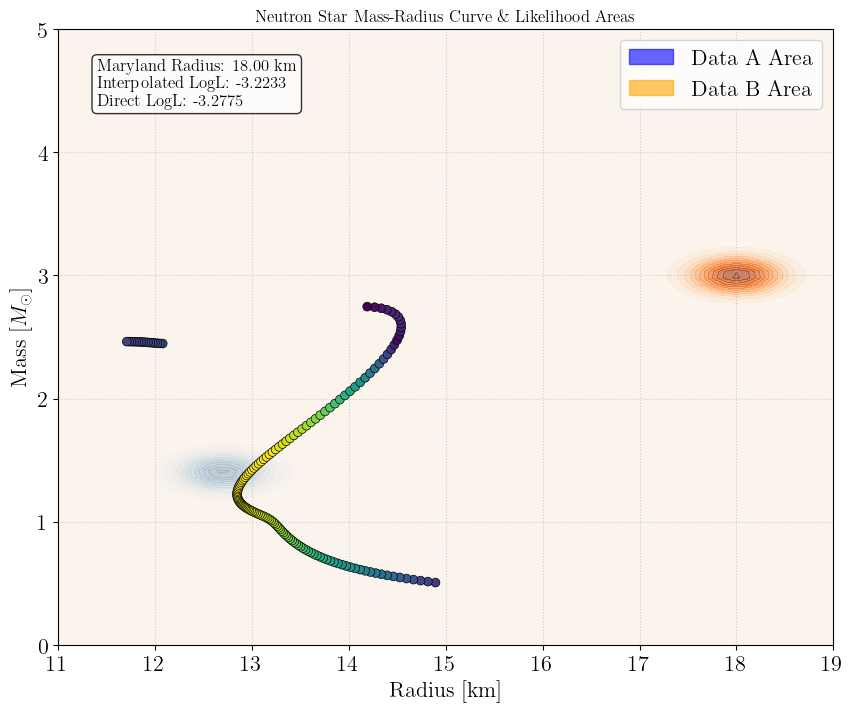

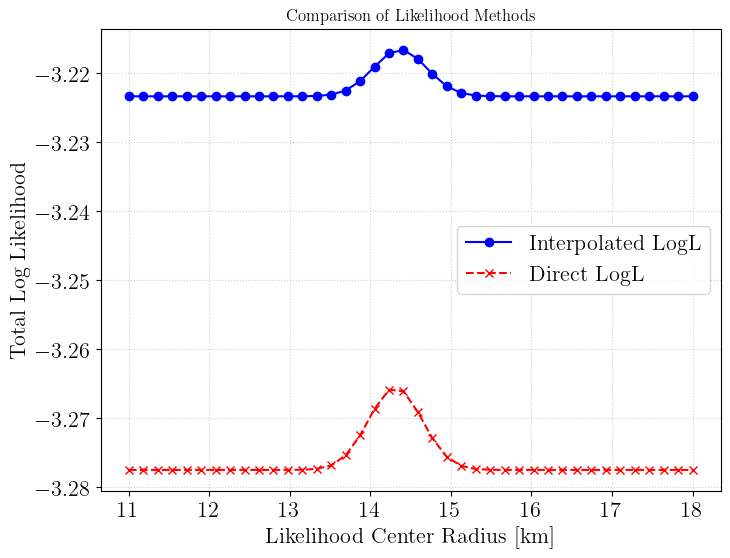

In [7]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
from types import SimpleNamespace
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
import jesterTOV.utils as utils


class LikelihoodTester:
    def __init__(self, amsterdam_masses, maryland_masses):
        self.penalty_value = -1e10
        self.N_masses_batch_size = 50
        
        self.amsterdam_fixed_mass_samples = amsterdam_masses
        self.maryland_fixed_mass_samples = maryland_masses
        
        # FIXED: Give the mock flows actual centers so they appear on the plot
        class MockFlow:
            def __init__(self, m_center, r_center):
                self.center = jnp.array([m_center, r_center])
                self.variance = jnp.array([0.01, 0.1]) # Mass var, Radius var

            def log_prob(self, mr_point):
                # mr_point shape is (..., 2)
                diff = mr_point - self.center
                return -0.5 * jnp.sum((diff ** 2) / self.variance, axis=-1) 
        
        # Centering them near realistic values for your dummy curve
        self.amsterdam_flow = MockFlow(1.4, 12.7)
        self.maryland_flow = MockFlow(3, 15)

    def evaluate(self, params: dict) -> float:
        masses_EOS = params["masses_EOS"]
        radii_EOS = params["radii_EOS"]
        mtov = jnp.max(masses_EOS)
        
        split_idx = utils.get_MR_split_index(masses_EOS, radii_EOS)
        
        idx = jnp.arange(masses_EOS.shape[0])
        mask1 = idx < split_idx
        mask2 = idx >= split_idx

        m_eos_1 = jnp.where(mask1, masses_EOS, jnp.inf)
        r_eos_1 = jnp.where(mask1, radii_EOS, 0.0)
        sort_1 = jnp.argsort(m_eos_1)
        m_eos_1, r_eos_1 = m_eos_1[sort_1], r_eos_1[sort_1]
        
        seg1_min = m_eos_1[0]
        seg1_max = jnp.max(jnp.where(m_eos_1 == jnp.inf, -jnp.inf, m_eos_1))

        m_eos_2 = jnp.where(mask2, masses_EOS, jnp.inf)
        r_eos_2 = jnp.where(mask2, radii_EOS, 0.0)
        sort_2 = jnp.argsort(m_eos_2)
        m_eos_2, r_eos_2 = m_eos_2[sort_2], r_eos_2[sort_2]

        seg2_min = m_eos_2[0]
        seg2_max = jnp.max(jnp.where(m_eos_2 == jnp.inf, -jnp.inf, m_eos_2))

        def process_sample_amsterdam(mass, m_eos, r_eos, max_m_tov, seg_min, seg_max):
            radius = jnp.interp(mass, m_eos, r_eos)
            mr_point = jnp.array([[mass, radius]])
            logpdf = self.amsterdam_flow.log_prob(mr_point)
            in_segment = (mass >= seg_min) & (mass <= seg_max)
            logpdf = jnp.where(in_segment, logpdf, -jnp.inf)
            penalty = jnp.where(mass > max_m_tov, self.penalty_value, 0.0)
            return logpdf + penalty

        def process_sample_maryland(mass, m_eos, r_eos, max_m_tov, seg_min, seg_max):
            radius = jnp.interp(mass, m_eos, r_eos)
            mr_point = jnp.array([[mass, radius]])
            logpdf = self.maryland_flow.log_prob(mr_point)
            in_segment = (mass >= seg_min) & (mass <= seg_max)
            logpdf = jnp.where(in_segment, logpdf, -jnp.inf)
            penalty = jnp.where(mass > max_m_tov, self.penalty_value, 0.0)
            return logpdf + penalty

        amsterdam_logprobs_1 = jax.lax.map(
            lambda m: process_sample_amsterdam(m, m_eos_1, r_eos_1, mtov, seg1_min, seg1_max),
            self.amsterdam_fixed_mass_samples,
        )

        maryland_logprobs_1 = jax.lax.map(
            lambda m: process_sample_maryland(m, m_eos_1, r_eos_1, mtov, seg1_min, seg1_max),
            self.maryland_fixed_mass_samples,
        )

        amsterdam_logprobs_2 = jax.lax.map(
            lambda m: process_sample_amsterdam(m, m_eos_2, r_eos_2, mtov, seg2_min, seg2_max),
            self.amsterdam_fixed_mass_samples,
        )

        maryland_logprobs_2 = jax.lax.map(
            lambda m: process_sample_maryland(m, m_eos_2, r_eos_2, mtov, seg2_min, seg2_max),
            self.maryland_fixed_mass_samples,
        )

        N_amsterdam = amsterdam_logprobs_1.shape[0]
        N_maryland = maryland_logprobs_1.shape[0]

        logL_amsterdam_1 = logsumexp(amsterdam_logprobs_1) - jnp.log(N_amsterdam) 
        logL_maryland_1 = logsumexp(maryland_logprobs_1) - jnp.log(N_maryland) 
        logL_amsterdam_2 = logsumexp(amsterdam_logprobs_2) - jnp.log(N_amsterdam) 
        logL_maryland_2 = logsumexp(maryland_logprobs_2) - jnp.log(N_maryland) 

        log_likelihood = logsumexp(
            jnp.array([logL_amsterdam_1, logL_maryland_1, logL_amsterdam_2, logL_maryland_2])
        ) - jnp.log(2.0)

        return log_likelihood


# 🧪 Execution logic
if __name__ == "__main__":
    # Assuming `data` is defined in your actual script
    test_params = {
        "masses_EOS": data["masses"],
        "radii_EOS": data["radii"]
    }
    
    key = jax.random.PRNGKey(42)
    key_ams, key_mary = jax.random.split(key)

    m_min = jnp.min(data["masses"])
    m_max = jnp.max(data["masses"])

    amsterdam_samples = jax.random.uniform(key_ams, (1000,), minval=m_min, maxval=m_max)
    maryland_samples = jax.random.uniform(key_mary, (1000,), minval=m_min, maxval=m_max)
    
    tester = LikelihoodTester(amsterdam_samples, maryland_samples)
    
    # Pre-compute grid for plotting
    r_grid = jnp.linspace(8.0, 19.0, 100) # Extended to 19 to fit the moving flow
    m_grid = jnp.linspace(0.0, 5.0, 100)
    R, M = jnp.meshgrid(r_grid, m_grid)
    grid_points = jnp.stack([M.ravel(), R.ravel()], axis=1)
    
    N_points = data["masses"].shape[0]
    curve_points = jnp.stack([data["masses"], data["radii"]], axis=1)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define animation parameters
    num_frames = 40
    radii_frames = jnp.linspace(11.0, 18.0, num_frames)
    
    def update(frame_idx):
        ax.clear()
        
        current_r = radii_frames[frame_idx]
        
        # Update the flow center physically
        tester.maryland_flow.center = jnp.array([3.0, current_r])
        
        # 1. Recalculate Interpolated Likelihood
        interp_logL = tester.evaluate(test_params)
        
        # 2. Recalculate Direct Likelihood
        log_probs_ams_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
        log_probs_mary_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)

        logL_ams_direct = logsumexp(log_probs_ams_direct) - jnp.log(N_points)
        logL_mary_direct = logsumexp(log_probs_mary_direct) - jnp.log(N_points)
        total_direct_logL = logsumexp(jnp.array([logL_ams_direct, logL_mary_direct])) - jnp.log(2.0)
        
        # 3. Recalculate Grid Probabilities
        amsterdam_grid_log_probs = jax.vmap(tester.amsterdam_flow.log_prob)(grid_points).reshape(100, 100)
        maryland_grid_log_probs = jax.vmap(tester.maryland_flow.log_prob)(grid_points).reshape(100, 100)
        
        amsterdam_probs = jnp.exp(amsterdam_grid_log_probs)
        maryland_probs = jnp.exp(maryland_grid_log_probs)
        
        # Plotting
        ax.contourf(R, M, amsterdam_probs, levels=15, cmap="Blues", alpha=0.6)
        ax.contourf(R, M, maryland_probs, levels=15, cmap="Oranges", alpha=0.6)
        
        total_curve_log_prob = jnp.logaddexp(log_probs_ams_direct, log_probs_mary_direct)
        
        sc = ax.scatter(
            data["radii"], 
            data["masses"], 
            c=total_curve_log_prob, 
            cmap="viridis", 
            s=40, 
            edgecolor="black", 
            linewidth=0.5, 
            zorder=10
        )
        
        # Add dynamic text to image
        textstr = (
            f"Maryland Radius: {current_r:.2f} km\n"
            f"Interpolated LogL: {interp_logL:.4f}\n"
            f"Direct LogL: {total_direct_logL:.4f}"
        )
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)

        ax.set_xlabel(r"Radius [km]")
        ax.set_ylabel(r"Mass [$M_{\odot}$]")
        ax.set_title(r"Neutron Star Mass-Radius Curve \& Likelihood Areas")
        
        legend_elements = [
            mpatches.Patch(color='blue', alpha=0.6, label='Data A Area'),
            mpatches.Patch(color='orange', alpha=0.6, label='Data B Area')
        ]
        ax.legend(handles=legend_elements, loc="upper right")
        
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_xlim(11, 19)
        ax.set_ylim(0.0, 5.0)

    print("Generating GIF. This will take a moment as it evaluates the physics for each frame...")
    ani = FuncAnimation(fig, update, frames=num_frames, interval=100)
    ani.save("maryland_flow_variation.gif", writer=PillowWriter(fps=2))
    print("Saved to maryland_flow_variation.gif")
    from IPython.display import Image, display

    # Display the GIF we generated and saved in the previous step
    display(Image(filename="maryland_flow_variation.gif"))

    # ==========================================
# Static Plot: Likelihood vs Maryland Radius
# ==========================================

# 1. Pre-allocate arrays for results
interp_logL_vals = []
direct_logL_vals = []

# 2. Compute Amsterdam direct log-likelihood once (it does not move)
log_probs_ams_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
logL_ams_direct = logsumexp(log_probs_ams_direct) - jnp.log(N_points)

print("Calculating likelihood values across radii...")

# 3. Iterate over the same radii frames
for r in radii_frames:
    # Update Maryland flow center
    tester.maryland_flow.center = jnp.array([3.0, r])
    
    # Calculate Interpolated LogL
    interp_logL = tester.evaluate(test_params)
    interp_logL_vals.append(interp_logL)
    
    # Calculate Direct LogL
    log_probs_mary_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    logL_mary_direct = logsumexp(log_probs_mary_direct) - jnp.log(N_points)
    
    total_direct_logL = logsumexp(jnp.array([logL_ams_direct, logL_mary_direct])) - jnp.log(2.0)
    direct_logL_vals.append(total_direct_logL)

# 4. Generate the plot
plt.figure(figsize=(8, 6))

plt.plot(radii_frames, interp_logL_vals, label="Interpolated LogL", marker='o', linestyle='-', color='blue')
plt.plot(radii_frames, direct_logL_vals, label="Direct LogL", marker='x', linestyle='--', color='red')

plt.xlabel(r"Likelihood Center Radius [km]")
plt.ylabel(r"Total Log Likelihood")
plt.title(r"Comparison of Likelihood Methods")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

Rendering Mass Sweep GIF...


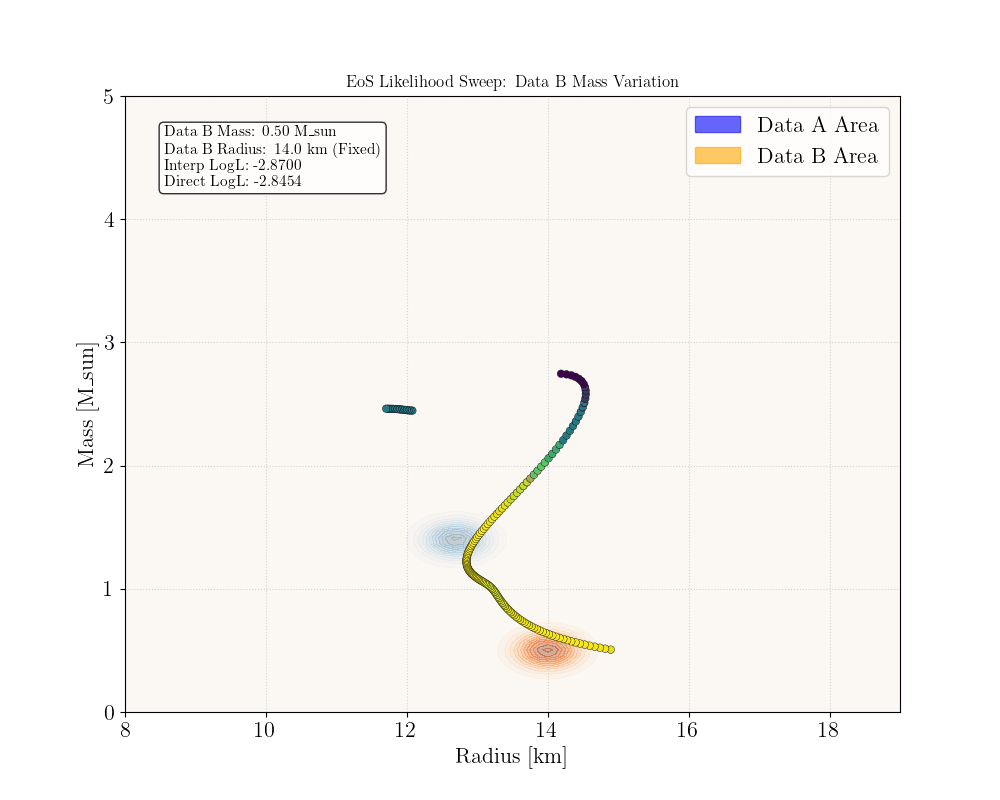

In [8]:
from IPython.display import Image, display

# 1. Setup parameter simulasi baru
num_frames_mass = 50
mass_frames = jnp.linspace(0.5, 4.0, num_frames_mass)
fixed_radius = 14.0

fig_m, ax_m = plt.subplots(figsize=(10, 8))

def update_mass(frame_idx):
    ax_m.clear()
    current_m = mass_frames[frame_idx]
    
    # Update Data B (Maryland) flow center: [Mass, Radius]
    tester.maryland_flow.center = jnp.array([current_m, fixed_radius])
    
    # Recalculate everything
    interp_logL = tester.evaluate(test_params)
    
    log_probs_A_direct = jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)
    log_probs_B_direct = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    
    logL_A_dir = logsumexp(log_probs_A_direct) - jnp.log(N_points)
    logL_B_dir = logsumexp(log_probs_B_direct) - jnp.log(N_points)
    total_direct_logL = logsumexp(jnp.array([logL_A_dir, logL_B_dir])) - jnp.log(2.0)
    
    # Grid for background contours
    grid_probs_A = jnp.exp(jax.vmap(tester.amsterdam_flow.log_prob)(grid_points).reshape(100, 100))
    grid_probs_B = jnp.exp(jax.vmap(tester.maryland_flow.log_prob)(grid_points).reshape(100, 100))
    
    # Plotting
    ax_m.contourf(R, M, grid_probs_A, levels=15, cmap="Blues", alpha=0.4)
    ax_m.contourf(R, M, grid_probs_B, levels=15, cmap="Oranges", alpha=0.4)
    
    # EOS Curve
    total_curve_log_p = jnp.logaddexp(log_probs_A_direct, log_probs_B_direct)
    sc = ax_m.scatter(data["radii"], data["masses"], c=total_curve_log_p, 
                     cmap="viridis", s=30, edgecolor="black", linewidth=0.3, zorder=10)
    
    # Text info
    textstr = (
        f"Data B Mass: {current_m:.2f} M_sun\n"
        f"Data B Radius: {fixed_radius} km (Fixed)\n"
        f"Interp LogL: {interp_logL:.4f}\n"
        f"Direct LogL: {total_direct_logL:.4f}"
    )
    ax_m.text(0.05, 0.95, textstr, transform=ax_m.transAxes, fontsize=11,
              verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_m.set_xlabel("Radius [km]")
    ax_m.set_ylabel("Mass [M_sun]")
    ax_m.set_title("EoS Likelihood Sweep: Data B Mass Variation")
    
    legend_elements = [
        mpatches.Patch(color='blue', alpha=0.6, label='Data A Area'),
        mpatches.Patch(color='orange', alpha=0.6, label='Data B Area')
    ]
    ax_m.legend(handles=legend_elements, loc="upper right")
    ax_m.set_xlim(8, 19)
    ax_m.set_ylim(0, 5)
    ax_m.grid(True, linestyle=":", alpha=0.5)

print("Rendering Mass Sweep GIF...")
ani_mass = FuncAnimation(fig_m, update_mass, frames=num_frames_mass, interval=80)
ani_mass.save("data_b_mass_sweep.gif", writer=PillowWriter(fps=2))
plt.close()

display(Image(filename="data_b_mass_sweep.gif"))

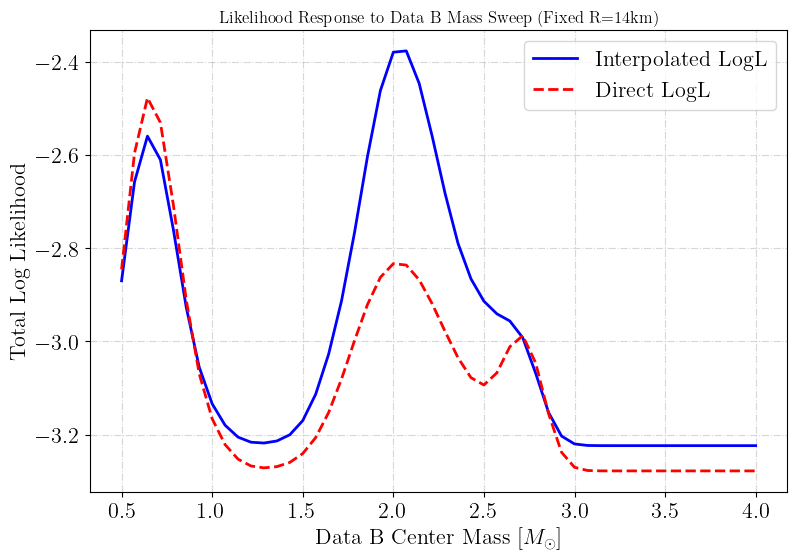

In [9]:
# Setup data collection
mass_interp_logL = []
mass_direct_logL = []

# Pre-calculate Data A direct (static)
logL_A_dir_static = logsumexp(jax.vmap(tester.amsterdam_flow.log_prob)(curve_points)) - jnp.log(N_points)

for m in mass_frames:
    tester.maryland_flow.center = jnp.array([m, fixed_radius])
    
    # Interpolated method
    mass_interp_logL.append(tester.evaluate(test_params))
    
    # Direct method
    log_probs_B = jax.vmap(tester.maryland_flow.log_prob)(curve_points)
    logL_B_dir = logsumexp(log_probs_B) - jnp.log(N_points)
    total_dir = logsumexp(jnp.array([logL_A_dir_static, logL_B_dir])) - jnp.log(2.0)
    mass_direct_logL.append(total_dir)

# Plotting the comparison
plt.figure(figsize=(9, 6))
plt.plot(mass_frames, mass_interp_logL, label="Interpolated LogL", color='blue', lw=2)
plt.plot(mass_frames, mass_direct_logL, label="Direct LogL", color='red', linestyle='--', lw=2)

# Mark the peak
# max_idx = jnp.argmax(jnp.array(mass_direct_logL))
# plt.axvline(mass_frames[max_idx], color='green', alpha=0.5, label=f'Peak at ~{mass_frames[max_idx]:.2f} M_sun')

plt.xlabel(r"Data B Center Mass [$M_{\odot}$]")
plt.ylabel("Total Log Likelihood")
plt.title("Likelihood Response to Data B Mass Sweep (Fixed R=14km)")
plt.legend()
plt.grid(True, which="both", ls="-.", alpha=0.5)
plt.show()

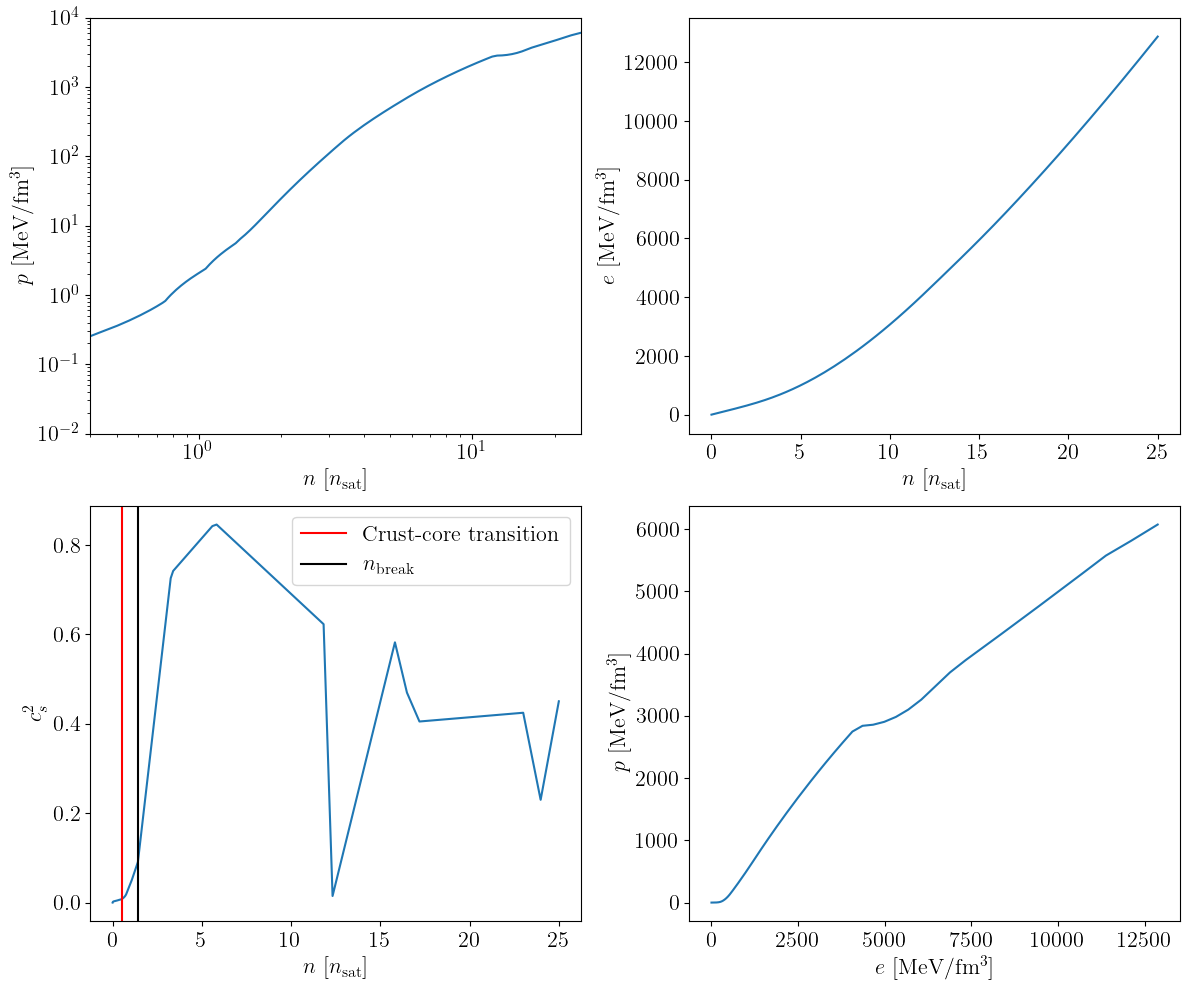

Running vmap for scalar-tensor calculations...
Scalar-tensor calculations for 1 beta values finished in 9.1217 seconds.


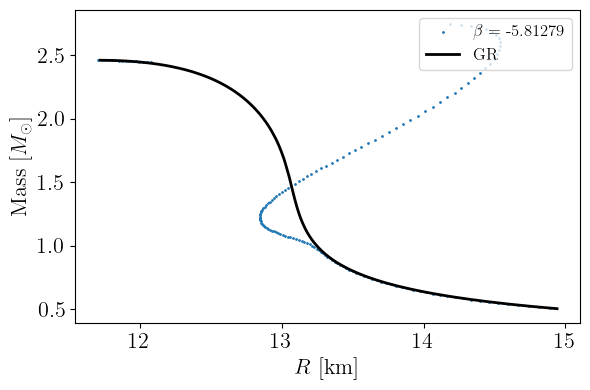

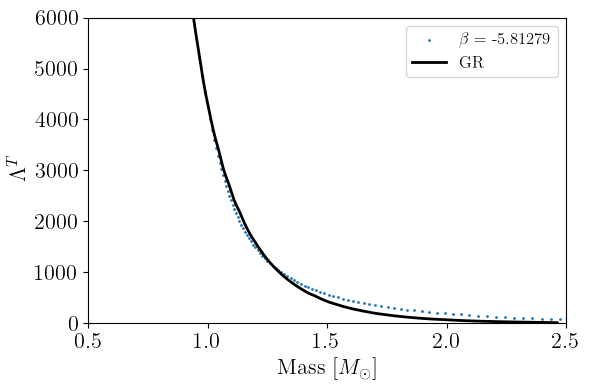

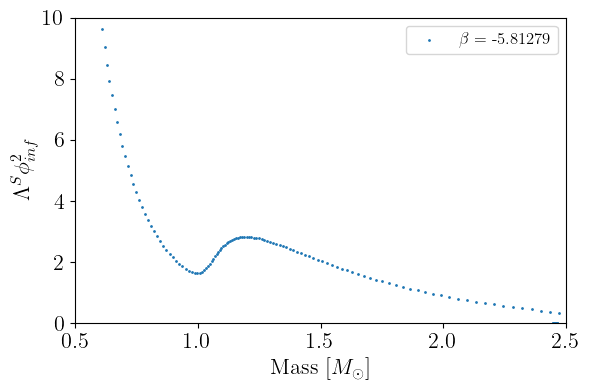

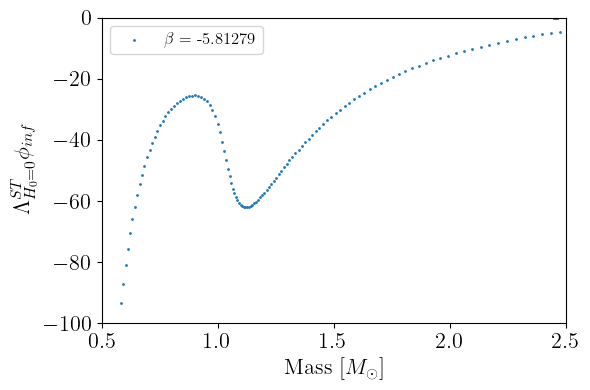

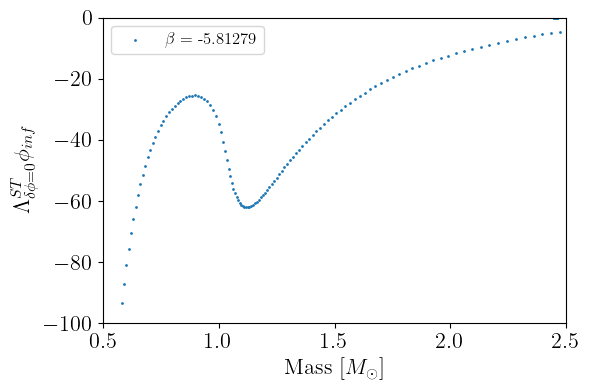

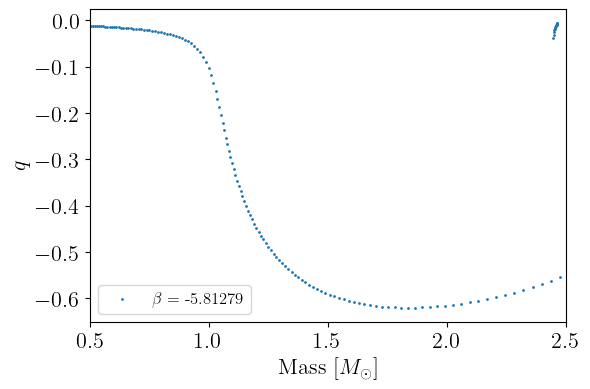

In [10]:
input_data_str =  """E_sat           | -1.60688e+01
E_sym           | 3.86202e+01
K_sat           | 1.65255e+02
K_sym           | 9.83160e+01
L_sym           | 2.35620e+01
Q_sat           | 2.45020e+02
Q_sym           | -6.95586e+02
Z_sat           | -4.46984e+02
Z_sym           | -1.72807e+03
_random_key     | 1.52656e+09
beta_ST         | -5.81279e+00
cs2_CSE_0       | 7.36893e-01
cs2_CSE_1       | 8.48778e-01
cs2_CSE_2       | 6.13429e-01
cs2_CSE_3       | 8.98158e-03
cs2_CSE_4       | 5.88126e-01
cs2_CSE_5       | 4.03804e-01
cs2_CSE_6       | 4.24797e-01
cs2_CSE_7       | 7.77889e-02
cs2_CSE_8       | 4.50180e-01
n_CSE_0_u       | 9.86674e-01
n_CSE_1_u       | 4.51662e-01
n_CSE_2_u       | 6.54113e-01
n_CSE_3_u       | 7.93539e-02
n_CSE_4_u       | 6.12247e-01
n_CSE_5_u       | 1.83258e-01
n_CSE_6_u       | 9.18473e-01
n_CSE_7_u       | 4.60962e-01
nbreak          | 2.26484e-01
"""

import jax.numpy as jnp                                                                                                   
import jax                                                                                                                
import matplotlib.pyplot as plt                                                                                           
import time                                                                                                               

from jesterTOV import utils
from jesterTOV.tov.data_classes import EOSData
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.scalar_tensor import ScalarTensorTOVSolver

# 1. Parse the provided input parameters
# input_data_str = """
# E_sat           | -1.59033e+01
# E_sym           | 3.22901e+01
# K_sat           | 2.61895e+02
# K_sym           | -2.74780e+02
# L_sym           | 7.34811e+01
# Q_sat           | 9.22315e+02
# Q_sym           | 1.01438e+03
# Z_sat           | -2.14998e+03
# Z_sym           | 1.25886e+03
# beta_ST         | -3.49905e+00
# cs2_CSE_0       | 5.56906e-01
# cs2_CSE_1       | 8.16552e-01
# cs2_CSE_2       | 5.65096e-02
# cs2_CSE_3       | 5.82637e-01
# cs2_CSE_4       | 8.20480e-02
# cs2_CSE_5       | 7.27966e-01
# cs2_CSE_6       | 6.29892e-01
# cs2_CSE_7       | 6.85474e-02
# cs2_CSE_8       | 1.24867e-01
# n_CSE_0_u       | 9.19373e-01
# n_CSE_1_u       | 5.41673e-01
# n_CSE_2_u       | 4.98518e-01
# n_CSE_3_u       | 1.53581e-01
# n_CSE_4_u       | 5.66337e-01
# n_CSE_5_u       | 2.58532e-02
# n_CSE_6_u       | 6.04648e-01
# n_CSE_7_u       | 7.44154e-01
# nbreak          | 2.58339e-01
# """

# input_data_str = """
# E_sat           | -1.60026e+01
# E_sym           | 2.98435e+01
# K_sat           | 1.81830e+02
# K_sym           | -6.34947e+01
# L_sym           | 3.44000e+01
# Q_sat           | 2.45076e+01
# Q_sym           | -3.07306e+02
# Z_sat           | -2.10266e+03
# Z_sym           | 7.83766e+02
# beta_ST         | -4.73928e+00
# cs2_CSE_0       | 3.03478e-01
# cs2_CSE_1       | 9.60489e-01
# cs2_CSE_2       | 3.80998e-01
# cs2_CSE_3       | 3.91384e-01
# cs2_CSE_4       | 6.16758e-01
# cs2_CSE_5       | 1.28236e-01
# cs2_CSE_6       | 2.07682e-01
# cs2_CSE_7       | 2.94126e-01
# cs2_CSE_8       | 3.20858e-02
# n_CSE_0_u       | 5.77547e-01
# n_CSE_1_u       | 7.18056e-01
# n_CSE_2_u       | 1.28820e-01
# n_CSE_3_u       | 3.08105e-01
# n_CSE_4_u       | 5.70248e-01
# n_CSE_5_u       | 2.54953e-01
# n_CSE_6_u       | 7.86629e-01
# n_CSE_7_u       | 8.25210e-01
# nbreak          | 2.14433e-01
# """

# input_data_str =  """
# E_sat           | -1.60688e+01
# E_sym           | 3.86202e+01
# K_sat           | 1.65255e+02
# K_sym           | 9.83160e+01
# L_sym           | 2.35620e+01
# Q_sat           | 2.45020e+02
# Q_sym           | -6.95586e+02
# Z_sat           | -4.46984e+02
# Z_sym           | -1.72807e+03
# _random_key     | 1.52656e+09
# beta_ST         | -5.81279e+00
# cs2_CSE_0       | 7.36893e-01
# cs2_CSE_1       | 8.48778e-01
# cs2_CSE_2       | 6.13429e-01
# cs2_CSE_3       | 8.98158e-03
# cs2_CSE_4       | 5.88126e-01
# cs2_CSE_5       | 4.03804e-01
# cs2_CSE_6       | 4.24797e-01
# cs2_CSE_7       | 7.77889e-02
# cs2_CSE_8       | 4.50180e-01
# n_CSE_0_u       | 9.86674e-01
# n_CSE_1_u       | 4.51662e-01
# n_CSE_2_u       | 6.54113e-01
# n_CSE_3_u       | 7.93539e-02
# n_CSE_4_u       | 6.12247e-01
# n_CSE_5_u       | 1.83258e-01
# n_CSE_6_u       | 9.18473e-01
# n_CSE_7_u       | 4.60962e-01
# nbreak          | 2.26484e-01
# """

input_dict = {}
for line in input_data_str.strip().split('\n'):
    key, val = line.split('|')
    input_dict[key.strip()] = float(val.strip())

# Extract beta_ST for the TOV solver
beta_values = [input_dict.pop("beta_ST")]

nsat = 0.16 # nuclear saturation density in fm^-3
nmax_nsat = 25.0
nb_CSE = 8 # Updated to 8 to match the provided inputs (indices 0 to 8)

# Define the EOS object, here we focus on Metamodel with CSE
# Note: assuming MetaModel_with_CSE_EOS_model is imported or defined elsewhere in your workspace
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=nb_CSE, nmin_MM_nsat=0.75, ndat_metamodel=80, ndat_CSE=70)

# Set the final grid density point explicitly as done in the original code
input_dict["n_CSE_8_u"] = nmax_nsat

# Now create the EOS, returns a tuple with most useful EOS quantities
eos_output = eos.construct_eos(input_dict)
ns, ps, hs, es, dloge_dlogps, mu, cs2 = eos_output.ns, eos_output.ps, eos_output.hs, eos_output.es, eos_output.dloge_dlogps, eos_output.mu, eos_output.cs2

# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.xscale('log')
plt.yscale('log')
plt.xlim(4e-1,25)
plt.ylim(1e-2,10000)
# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(input_dict["nbreak"] / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show() # uncomment to see the EOS
plt.close()

# Parameters for TOV
phi_c = 1.0
phi_inf_tgt = 1e-3

# Create EOSData 
eos_data = EOSData(
  ns=ns,
  ps=ps,
  hs=hs,
  es=es,
  dloge_dlogps=dloge_dlogps,
  cs2=cs2,
)

# Create solvers
gr_solver = GRTOVSolver()
st_solver = ScalarTensorTOVSolver()

print("Running vmap for scalar-tensor calculations...")

def solve_for_beta(beta_ST):
    tov_params = {
        "beta_ST": beta_ST,
        "phi_c": phi_c,
        "phi_inf_tgt": phi_inf_tgt
    }
    family = st_solver.construct_family(
      eos_data,
      ndat=200,
      min_nsat=0.1,
      tov_params=tov_params
    )
    return family

beta_array = jnp.array(beta_values)

start_time = time.time()
solve_for_beta_vmapped = jax.vmap(solve_for_beta)
st_families = solve_for_beta_vmapped(beta_array)

st_masses = st_families.masses
st_radii = st_families.radii
st_lambdas = st_families.lambdas
st_extra = st_families.extra  # Dictionary with solver-specific fields

st_masses.block_until_ready()
end_time = time.time()
duration = end_time - start_time
print(f"Scalar-tensor calculations for {len(beta_values)} beta values finished in {duration:.4f} seconds.")

# Collect results, filter out NaN values
results = {}
r_max = 50  # km
for i, beta_ST in enumerate(beta_values):
    radii_km = st_radii[i]
    masses_solar = st_masses[i]
    lambdas = st_lambdas[i]
    
    # Access extra fields from the dict
    mask = (radii_km < r_max) & (radii_km > 5) & (masses_solar > 0.5) & jnp.isfinite(st_extra["lambda_S"][i])
    
    results[beta_ST] = {
      "masses": masses_solar[mask],
      "radii": radii_km[mask],
      "lambdas": lambdas[mask],
      "lambdas_S": st_extra["lambda_S"][i][mask],
      "lambdas_ST1": st_extra["lambda_ST1"][i][mask],
      "lambdas_ST2": st_extra["lambda_ST2"][i][mask],
      "qs": st_extra["q"][i][mask],
    }

# GR reference
gr_family = gr_solver.construct_family(eos_data, ndat=300, min_nsat=0.5, tov_params={})
gr_mask = (gr_family.radii < r_max) & (gr_family.radii > 5) & (gr_family.masses > 0.5)
gr_masses = gr_family.masses[gr_mask]
gr_lambdas = gr_family.lambdas[gr_mask]
gr_radii = gr_family.radii[gr_mask]

# ============================================
# Plot 0: Mass vs Radius
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["radii"], data["masses"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_radii, gr_masses, label='GR', color='black', linewidth=2)
plt.ylabel(r"Mass [$M_\odot$]")
plt.xlabel(r"$R$ [km]")
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 1: Tensor tidal deformability Λ^T vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.plot(gr_masses, gr_lambdas, label='GR', color='black', linewidth=2)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^T$")
plt.ylim(0, 6000)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 2: Scalar tidal deformability Λ^S * φ_inf^2 vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_S"] * phi_inf_tgt**2, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^S \phi_{inf}^2$")
plt.ylim(0, 10)
plt.xlim(0.5, 2.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 3: Mixed tidal deformability Λ^ST1 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST1"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{H_0 = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 4: Mixed tidal deformability Λ^ST2 * φ_inf vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
    plt.scatter(data["masses"], data["lambdas_ST2"] * phi_inf_tgt, label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$\Lambda^{ST}_{\delta \phi = 0} \phi_{inf}$")
plt.ylim(-100, 0)
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# ============================================
# Plot 5: Scalar charge q vs Mass
# ============================================
plt.figure(figsize=(6, 4))
for beta_ST, data in results.items():
  plt.scatter(data["masses"], data["qs"], label=rf'$\beta$ = {beta_ST}', s=1)
plt.xlabel(r"Mass [$M_\odot$]")
plt.ylabel(r"$q$")
plt.xlim(0.5, 2.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

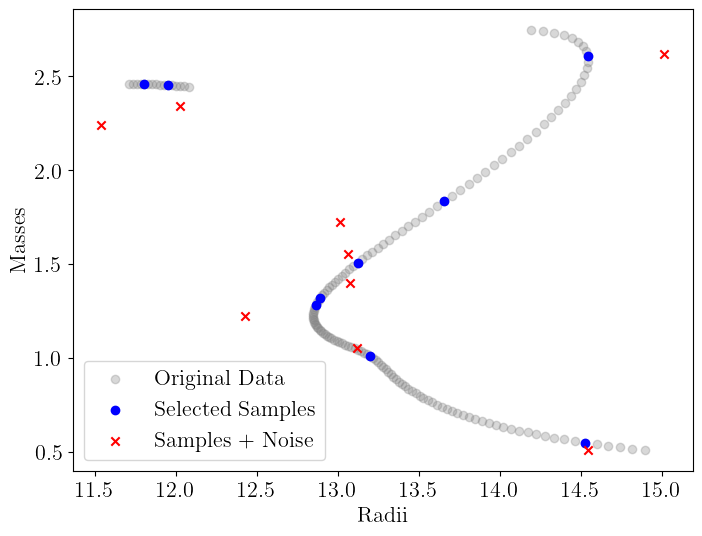

In [12]:
from jax import random
key = jax.random.PRNGKey(12)

# Ambil jumlah data
n_data = data["radii"].shape[0]

# Ambil 5 index unik (replace=False biar gak ada duplikat)
indices = jax.random.choice(key, n_data, shape=(9,), replace=False)

# Fancy indexing ala JAX/Numpy
sample_radii = data["radii"][indices]
sample_masses = data["masses"][indices]
# 1. JAX butuh PRNGKey! Kita mulai dari seed 0 (atau angka hoki kamu)
key = random.PRNGKey(92)

# Pisahkan key untuk masing-masing variabel (best practice JAX)
key_r, key_m = random.split(key, 2)

# 2. Hitung deviasi (pake jnp ya, jangan np!)
sigma_r = 0.02 * sample_radii
sigma_m = 0.05 * sample_masses
# 3. Generate noise dengan JAX
# Syntax: random.normal(key, shape)
noise_r = random.normal(key_r, shape=sample_radii.shape) * sigma_r
noise_m = random.normal(key_m, shape=sample_masses.shape) * sigma_m

sample_radii_noise = sample_radii + noise_r
sample_masses_noise = sample_masses + noise_m

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Original Data", color='gray')
plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
plt.scatter(sample_radii_noise, sample_masses_noise, label="Samples + Noise", color='red', marker='x')
plt.legend()
plt.xlabel("Radii")
plt.ylabel("Masses")
plt.show()

=== Sample Parameters Table ===
 Sample Mass_Center Radius_Center Mass_Center_Noise Radius_Center_Noise Std_Mass Std_Radius Covariance Skew_Mass Skew_Radius
      1       2.461        11.806             2.242              11.537    0.069      0.290      0.015     0.592      -2.064
      2       1.507        13.121             1.552              13.059    0.058      0.112      0.006     0.607       1.248
      3       0.547        14.525             0.508              14.543    0.051      0.294      0.012    -1.726      -1.909
      4       2.454        11.950             2.341              12.022    0.059      0.161      0.005    -0.408      -1.253
      5       1.283        12.865             1.224              12.426    0.081      0.128      0.003    -0.802      -0.264
      6       2.608        14.539             2.619              15.013    0.089      0.140      0.006     0.554      -2.721
      7       1.009        13.198             1.053              13.118    0.080      0.134  

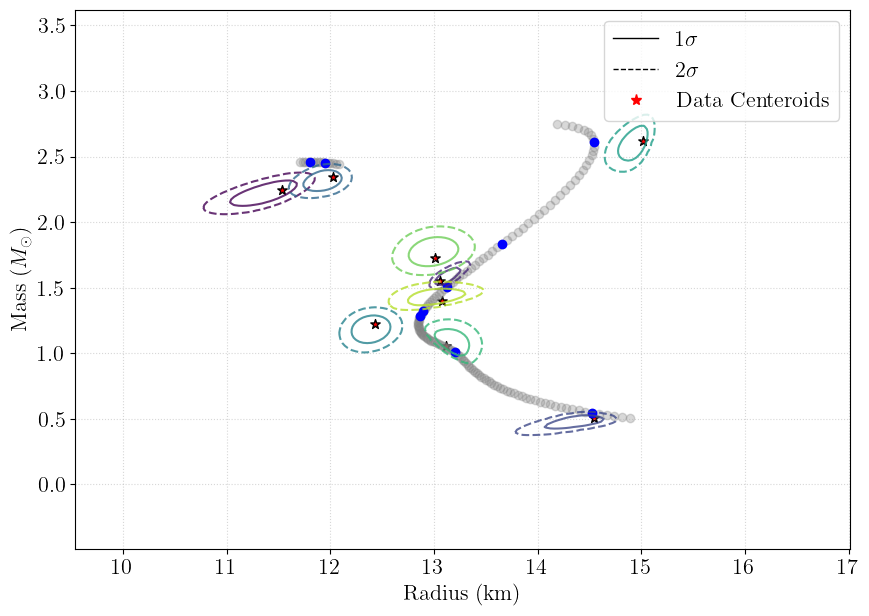

In [13]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SkewedCorrelatedFlow:
    def __init__(self, m_center, r_center, cov_matrix, skewness):
        """
        m_center, r_center: Mean (2,)
        cov_matrix: Covariance matrix (2, 2) - Must be Positive Definite.
        skewness: Skewness vector (2,)
        """
        self.center = jnp.array([m_center, r_center])
        self.cov = jnp.array(cov_matrix)
        self.skew = jnp.array(skewness)
        
        # Precompute precision (inverse cov) and constant for log_prob
        self.inv_cov = jnp.linalg.inv(self.cov)
        self.log_det_cov = jnp.linalg.slogdet(self.cov)[1]

    def log_prob(self, mr_point):
        # mr_point shape: (..., 2)
        diff = mr_point - self.center
        
        # 1. Standard Multivariate Normal Part
        quad_form = jnp.sum(diff @ self.inv_cov * diff, axis=-1)
        log_norm = -0.5 * (self.log_det_cov + quad_form + 2 * jnp.log(2 * jnp.pi))
        
        # 2. Skewness Part
        omega = jnp.sqrt(jnp.diag(self.cov))
        alpha_prime = self.skew / omega
        
        skew_arg = jnp.sum(alpha_prime * diff, axis=-1)
        log_skew = jnp.log(2.0) + jax.scipy.stats.norm.logcdf(skew_arg)
        
        return log_norm + log_skew

# Dummy data generation (assuming these were your inputs)
np.random.seed(42) # For reproducible random parameter generation
n_samples = len(sample_masses_noise)


flows = []
table_data = []

# Generate different deviation, covariance, and skew for each sample
for i, (m, r) in enumerate(zip(sample_masses_noise, sample_radii_noise)):
    # Random standard deviations and correlation
    std_m = np.random.uniform(0.05, 0.1)
    std_r = np.random.uniform(0.1, 0.3)
    corr = np.random.uniform(0, 1) # Bounded to ensure positive definiteness
    
    # Construct covariance matrix
    cov_val = corr * std_m * std_r
    cov_m = jnp.array([
        [std_m**2, cov_val], 
        [cov_val,  std_r**2]
    ])
    
    # Random skewness
    skew_v = jnp.array([np.random.uniform(-3.0, 3.0), np.random.uniform(-3.0, 3.0)])
    
    # Initialize flow
    flows.append(SkewedCorrelatedFlow(m, r, cov_m, skew_v))
     
    # Store parameters for the table
    table_data.append({
        "Sample": i + 1,
        "Mass_Center": f"{sample_masses[i]:.3f}",
        "Radius_Center": f"{sample_radii[i]:.3f}",
        "Mass_Center_Noise": f"{m:.3f}",
        "Radius_Center_Noise": f"{r:.3f}",
        "Std_Mass": f"{std_m:.3f}",
        "Std_Radius": f"{std_r:.3f}",
        "Covariance": f"{cov_val:.3f}",
        "Skew_Mass": f"{skew_v[0]:.3f}",
        "Skew_Radius": f"{skew_v[1]:.3f}"
    })

# Print the parameter table
df_params = pd.DataFrame(table_data)
print("=== Sample Parameters Table ===")
print(df_params.to_string(index=False))
print("===============================\n")

def plot_mock_flows_contours(flows, samples_m, samples_r):
    m_grid = jnp.linspace(jnp.min(samples_m) - 1, jnp.max(samples_m) + 1, 200)
    r_grid = jnp.linspace(jnp.min(samples_r) - 2, jnp.max(samples_r) + 2, 200)
    M, R = jnp.meshgrid(m_grid, r_grid)
    grid_points = jnp.stack([M, R], axis=-1)

    plt.figure(figsize=(10, 7))
    cmap = plt.get_cmap('viridis')
    n_flows = len(flows)

    for i, flow in enumerate(flows):
        color = cmap(i / n_flows)
        
        # 1. Evaluate probability
        lp = flow.log_prob(grid_points)
        prob = jnp.exp(lp)
        
        # 2. Sort descending
        prob_flat = prob.flatten()
        sorted_prob = jnp.sort(prob_flat)[::-1]
        
        # 3. Accumulate and normalize to exactly 1 over the grid
        cum_prob = jnp.cumsum(sorted_prob)
        cum_prob = cum_prob / cum_prob[-1] 
        
        # 4. Identify thresholds for 1-sigma (68.27%) and 2-sigma (95.45%)
        idx_1sigma = jnp.searchsorted(cum_prob, 0.6827)
        idx_2sigma = jnp.searchsorted(cum_prob, 0.9545)
        
        level_1sigma = sorted_prob[idx_1sigma]
        level_2sigma = sorted_prob[idx_2sigma]
        
        # 5. Draw contours
        plt.contour(R, M, prob, levels=[level_2sigma, level_1sigma], 
                    colors=[color], alpha=0.8, linestyles=['dashed', 'solid'])
        
        # Corrected Center Plotting
        plt.scatter(flow.center[1], flow.center[0], color='red', 
                    marker='*', s=50, edgecolors='black', 
                    label='Data Centers' if i == 0 else "")
    plt.scatter(data["radii"], data["masses"], alpha=0.3, label="Reference masses radii", color='gray')
    plt.scatter(sample_radii, sample_masses, label="Selected Samples", color='blue')
    plt.ylabel(r"Mass ($M_{\odot}$)")
    plt.xlabel("Radius (km)")
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # Custom legend for contour lines
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='black', lw=1, linestyle='solid'),
                    Line2D([0], [0], color='black', lw=1, linestyle='dashed'),
                    Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=8)]
    plt.legend(custom_lines, [r'$1\sigma$', r'$2\sigma$', 'Data Centeroids'])
    
    plt.show()

# Execute plot
plot_mock_flows_contours(flows, sample_masses_noise, sample_radii_noise)